# 01b – Patterns: NYC Citi Bike

**Worked on by:** Andreas Schellekens (weather data, weather effects on daily demand, time patterns)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant). All findings and decisions were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup

This notebook builds on `01a_eda_data_quality.ipynb`: it reads the Parquet layer that 01a created (`Data/parquet/trips/`, 323,817,107 trips) with DuckDB, and uses the same plot style. Run 01a first.

01a found the patterns worth explaining: commuting peaks on working days, leisure at weekends, seasonal casual riders, the rise of the electric bike, and 10 days without trips that looked like storms. This notebook looks for the **causes and the size** of those patterns, with statistical evidence. Its first question is what the weather does to the number of trips.

In [1]:
import os
import time
import urllib.request
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)

# The plot style of 01a, so the notebooks look alike
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "text.color": INK_PRIMARY, "axes.titlesize": 12, "axes.titleweight": "bold",
})
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
USER_COLOURS = {"member": BLUE, "casual": ORANGE}

DATA_DIR = Path("Data")
PARQUET_DIR = DATA_DIR / "parquet" / "trips"
WEATHER_DIR = DATA_DIR / "weather"  # git-ignored like all of Data/
FIRST_DAY, LAST_DAY = "2013-06-01", "2026-08-31"

con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
con.execute("INSTALL icu; LOAD icu")  # time-zone support for the corrected duration
print("DuckDB", duckdb.__version__)

DuckDB 1.5.6


### 1.1 The cleaned trips

01a decided which trips to remove and how to correct the duration (01a, sections 7.5 and 9). Until the data-preparation notebook writes a cleaned dataset, we apply those rules on the fly with the same SQL as 01a section 8: the view `clean_trips` drops trips over 24 hours (rule D2), trips from or to non-public stations (S3) and round trips under 3 minutes (R1), and adds the corrected `duration` (D1).

In [2]:
CORRECTED_DURATION = """
    CASE WHEN source_format <> 'new' THEN tripduration_s
         ELSE date_diff('millisecond', timezone('America/New_York', started_at),
                                       timezone('America/New_York', ended_at)) / 1000.0
              + CASE WHEN ended_at < started_at THEN 3600 ELSE 0 END
    END
"""
NON_PUBLIC = ("'^(NYCBS Depot|NYCBS Test|8D |Kiosk in a box|Mobile 01|GOW Tech Shop|Shop Morgan|Lab - NYC|"
              "Prototype Lab|LA Metro Demo|MTL-)'")
REMOVE_RULES = f"""
    duration > 24 * 3600
    OR regexp_matches(coalesce(start_station_name, ''), {NON_PUBLIC})
    OR regexp_matches(coalesce(end_station_name, ''), {NON_PUBLIC})
    OR (start_station_id = end_station_id AND duration < 180)
"""
con.execute(f"CREATE OR REPLACE VIEW trips AS SELECT * FROM read_parquet('{PARQUET_DIR.as_posix()}/*.parquet')")
con.execute(f"""
    CREATE OR REPLACE VIEW clean_trips AS
    SELECT * FROM (SELECT *, {CORRECTED_DURATION} AS duration FROM trips) WHERE NOT ({REMOVE_RULES})
""")
print("Views trips and clean_trips are ready")

Views trips and clean_trips are ready


## 2. Daily demand and the weather

Bike trips are made outdoors, so the weather should matter. 01a already found days without any trips in winter. Here we measure how much rain, snow and temperature change the number of trips per day, and whether members and casual riders react differently.

### 2.1 The weather data

We use the daily observations of the **Central Park weather station** (station `USW00094728`) from NOAA's Global Historical Climatology Network (GHCN-Daily). It is the official weather station of New York City, in the middle of the area the bikes cover, and the data is free without an account. The file holds the whole history of the station (since 1869, about 18 MB); it is downloaded once and then read from disk. (Path not taken: the Open-Meteo archive, which gives modelled values on a grid instead of measurements at a station.)

In [3]:
WEATHER_URL = ("https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/"
               "USW00094728.csv")
WEATHER_FILE = WEATHER_DIR / "USW00094728.csv"

if not WEATHER_FILE.exists():
    WEATHER_DIR.mkdir(parents=True, exist_ok=True)
    temporary = WEATHER_FILE.with_suffix(".csv.part")  # a half download never looks like a finished file
    urllib.request.urlretrieve(WEATHER_URL, temporary)
    os.replace(temporary, WEATHER_FILE)
    print("Downloaded", WEATHER_FILE)
print(f"{WEATHER_FILE}: {WEATHER_FILE.stat().st_size / 1e6:.1f} MB")

Data\weather\USW00094728.csv: 17.8 MB


GHCN-Daily stores whole numbers in fixed units: precipitation in tenths of a millimetre, snowfall and snow depth in millimetres, temperatures in tenths of a degree Celsius and wind speed in tenths of a metre per second. We keep the period of the trip data and convert to ordinary units. Precipitation is the total of rain and melted snow over the day.

In [4]:
raw = pd.read_csv(WEATHER_FILE, usecols=["DATE", "PRCP", "SNOW", "SNWD", "TMAX", "TMIN", "AWND"],
                  parse_dates=["DATE"], low_memory=False)
raw = raw[(raw.DATE >= FIRST_DAY) & (raw.DATE <= LAST_DAY)].set_index("DATE")
weather = pd.DataFrame({
    "tmax_c": raw.TMAX / 10,
    "tmin_c": raw.TMIN / 10,
    "precipitation_mm": raw.PRCP / 10,
    "snowfall_mm": raw.SNOW,
    "snow_depth_mm": raw.SNWD,
    "wind_ms": raw.AWND / 10,
})
all_days = pd.date_range(FIRST_DAY, LAST_DAY, freq="D")
print(f"{len(weather):,} of {len(all_days):,} days present; missing values per column:")
print(weather.isna().sum().to_string())
weather.describe().round(1)

4,840 of 4,840 days present; missing values per column:
tmax_c                0
tmin_c                0
precipitation_mm      0
snowfall_mm           0
snow_depth_mm         4
wind_ms             226


,tmax_c,tmin_c,precipitation_mm,snowfall_mm,snow_depth_mm,wind_ms
count,4840.0,4840.0,4840.0,4840.0,4836.0,4614.0
mean,17.7,9.9,3.4,1.9,8.5,2.3
std,10.0,9.2,9.5,18.7,43.0,1.1
min,-10.5,-18.2,0.0,0.0,0.0,0.0
25%,9.4,2.8,0.0,0.0,0.0,1.5
50%,18.6,10.0,0.0,0.0,0.0,2.1
75%,26.7,18.3,1.5,0.0,0.0,2.9
max,37.8,28.3,181.1,693.0,560.0,8.2


The station has a value for every day of the period, except snow depth on 4 days and wind speed on 226 days. Temperature and precipitation, the two variables we need most, are complete. The ranges are plausible for New York: maximum temperatures from -10.5 to 37.8 degrees, no precipitation on more than half of the days (median 0 mm), and up to 181 mm on the wettest day.

### 2.2 Daily trips

The number of cleaned trips per day, split by user type, from DuckDB. A day without any trip gets 0. Trips without a user type (51,780 in 2016-2017, rule U1) only count in the total.

In [5]:
start = time.time()
daily_by_user = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, coalesce(user_type, 'unknown') AS user_type, count(*) AS trips
    FROM clean_trips WHERE started_at >= DATE '2013-06-01' GROUP BY ALL
""").df()
daily_by_user["day"] = pd.to_datetime(daily_by_user.day)
daily = (daily_by_user.pivot_table(index="day", columns="user_type", values="trips", aggfunc="sum")
         .reindex(all_days, fill_value=0).fillna(0).astype(int))
daily["total"] = daily.sum(axis=1)

days = weather.join(daily[["total", "member", "casual"]])
days["weekday"] = days.index.dayofweek  # pandas: 0 = Monday ... 6 = Sunday
days["year_month"] = days.index.strftime("%Y-%m")
print(f"{len(days):,} days, {days.total.sum():,} trips (built in {time.time() - start:.0f} s)")
days.head(3)

4,840 days, 321,939,739 trips (built in 35 s)


,tmax_c,tmin_c,precipitation_mm,snowfall_mm,snow_depth_mm,wind_ms,total,member,casual,weekday,year_month
DATE,,,,,,,,,,,
2013-06-01,32.2,22.8,0.0,0.0,0.0,1.7,8498,4988,3510,5,2013-06
2013-06-02,31.1,20.6,21.6,0.0,0.0,2.7,15593,5102,10491,6,2013-06
2013-06-03,25.6,18.9,22.1,0.0,0.0,1.5,7426,4506,2920,0,2013-06


### 2.3 The days without trips were snowstorms

01a found 10 days without any trip and guessed that they were storms. With the weather data we can check that, together with the two almost empty days and the very quiet 25 January 2026.

In [6]:
storm_check = ["2016-01-23", "2016-01-24", "2016-01-25", "2016-01-26", "2017-02-09", "2017-03-14", "2017-03-15",
               "2017-03-16", "2020-12-17", "2021-02-01", "2021-02-02", "2026-01-25", "2026-02-22", "2026-02-23"]
days.loc[storm_check, ["total", "tmax_c", "precipitation_mm", "snowfall_mm", "snow_depth_mm", "wind_ms"]]

,total,tmax_c,precipitation_mm,snowfall_mm,snow_depth_mm,wind_ms
DATE,,,,,,
2016-01-23,0,-2.7,58.7,693.0,150.0,7.0
2016-01-24,0,1.7,0.0,0.0,560.0,2.6
2016-01-25,0,3.9,0.0,0.0,480.0,1.5
2016-01-26,0,8.9,0.0,0.0,430.0,2.9
2017-02-09,0,6.7,29.5,239.0,50.0,5.5
2017-03-14,0,0.0,50.0,193.0,100.0,6.0
2017-03-15,0,-3.2,0.0,0.0,150.0,5.2
2017-03-16,0,3.9,0.0,0.0,130.0,3.5
2020-12-17,175,0.6,16.8,102.0,230.0,4.2


Every one of them is a snowstorm or the day after one. On 23 January 2016, 693 mm of snow fell (the blizzard of 2016), and 56 cm still lay on the ground the next day; on 9 February 2017, 239 mm; on 14 March 2017, 193 mm; on 17 December 2020, 102 mm; on 1 February 2021, 376 mm; on 25 January 2026, 290 mm; on 22 and 23 February 2026, 224 and 277 mm. On the days without trips the system was evidently closed; on the days after, it reopened while there was still snow on the ground. This confirms the decision of 01a to keep these days: they are real events, and the weather explains them.

### 2.4 A first look: temperature and rain

The number of trips grows over the years and changes with the season, so a raw scatter of trips against temperature mixes three things. To compare days fairly we first divide each day's trips by the average of the same month and the same kind of day (working day or weekend). A value of 1.2 then means "20% more trips than a normal day of that kind in that month". The left chart shows this relative demand against the maximum temperature, the right one per precipitation class.

precipitation
dry           3136
light          674
moderate       493
heavy          368
very heavy     169


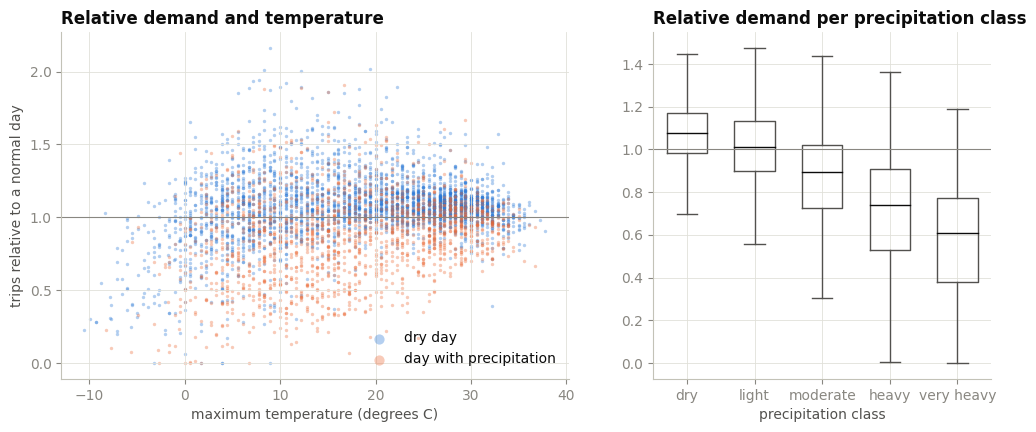

In [7]:
PRECIPITATION_CLASSES = ["dry", "light", "moderate", "heavy", "very heavy"]
days["precipitation"] = pd.cut(days.precipitation_mm, [-0.1, 0, 2.5, 10, 25, np.inf],
                               labels=PRECIPITATION_CLASSES)
days["weekend"] = days.weekday >= 5
days["relative"] = days.total / days.groupby(["year_month", "weekend"]).total.transform("mean")
print(days.precipitation.value_counts().reindex(PRECIPITATION_CLASSES).to_string())

fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [3, 2]})
dry = days.precipitation == "dry"
left.scatter(days.tmax_c[dry], days.relative[dry], s=6, color=BLUE, alpha=0.35, linewidth=0, label="dry day")
left.scatter(days.tmax_c[~dry], days.relative[~dry], s=6, color=ORANGE, alpha=0.35, linewidth=0,
             label="day with precipitation")
left.axhline(1, color=INK_MUTED, linewidth=0.8)
left.set_xlabel("maximum temperature (degrees C)")
left.set_ylabel("trips relative to a normal day")
left.set_title("Relative demand and temperature", loc="left")
left.legend(loc="lower right", frameon=False, markerscale=3)

groups = [days.relative[days.precipitation == c].dropna() for c in PRECIPITATION_CLASSES]
right.boxplot(groups, labels=PRECIPITATION_CLASSES, showfliers=False, widths=0.6,
              medianprops={"color": INK_PRIMARY}, boxprops={"color": INK_SECONDARY},
              whiskerprops={"color": INK_SECONDARY}, capprops={"color": INK_SECONDARY})
right.axhline(1, color=INK_MUTED, linewidth=0.8)
right.set_title("Relative demand per precipitation class", loc="left")
right.set_xlabel("precipitation class")
plt.show()

Both effects are visible without any model. Relative demand rises steeply with temperature up to about 25 degrees and flattens above it; most days far below normal are wet days (orange), the others are very cold days. Per precipitation class (dry: 0 mm, light: up to 2.5 mm, moderate: 2.5-10 mm, heavy: 10-25 mm, very heavy: over 25 mm) the median falls step by step, and the boxes of dry and very heavy days do not overlap at all. More than half of the days (3,136) are dry, so there is plenty of data for every class.

But temperature and rain are not independent (cold days are often grey, summer storms are hot), so the next step separates them in one model.

### 2.5 The weather effects in one model

We fit a linear regression on the **logarithm** of the daily trips. In a log model a coefficient translates into a percentage change, which is what we want ("rain costs 20% of the trips"), and the effect of rain is then allowed to be larger in absolute numbers on a busy summer day than on a quiet winter day. The explanatory variables:

- **maximum temperature** and its square, so that the effect may flatten or turn on hot days;
- the **precipitation class** (dry is the reference);
- **snow on the ground** (snow depth above 0), because snow hinders cycling on the days after a storm as well;
- the **weekday** (a Saturday differs from a Monday whatever the weather);
- the **month** of every year separately (`year_month`, 159 values). This absorbs the growth of the system, the seasons and events such as the COVID-19 lockdown, so the weather effects are measured **within** a month: a rainy Tuesday is compared with dry Tuesdays of the same month.

The 10 days without trips are left out: their logarithm does not exist, and 2.3 already explains them. Neighbouring days are not independent (weather and use come in spells), so ordinary standard errors would be too optimistic; we use Newey-West (HAC) standard errors that allow correlation between days up to a week apart. With about 4,800 days the p-values are meaningful here, but we report the effect sizes with 95% confidence intervals, which say more.

In [8]:
model_data = days[days.total > 0].copy()
model_data["snow_on_ground"] = (model_data.snow_depth_mm > 0).astype(int)
FORMULA = ("np.log({target}) ~ tmax_c + I(tmax_c ** 2) + C(precipitation) + snow_on_ground"
           " + C(weekday) + C(year_month)")


def fit_weather_model(target, data=model_data, extra=""):
    """Log-linear model of daily trips with weather, weekday and year-month effects (HAC standard errors)."""
    return smf.ols(FORMULA.format(target=target) + extra, data=data).fit(cov_type="HAC", cov_kwds={"maxlags": 7})


def weather_effects(model):
    """Percentage effect of each weather term with its 95% confidence interval."""
    terms = [t for t in model.params.index if t.startswith("C(precipitation)") or t == "snow_on_ground"]
    ci = model.conf_int().loc[terms]
    return pd.DataFrame({
        "effect_pct": 100 * (np.exp(model.params[terms]) - 1),
        "ci_low_pct": 100 * (np.exp(ci[0]) - 1),
        "ci_high_pct": 100 * (np.exp(ci[1]) - 1),
    }).rename(index=lambda t: t.replace("C(precipitation)[T.", "").replace("]", "").replace("_", " ")).round(1)


TEMPERATURE_TERMS = ["tmax_c", "I(tmax_c ** 2)"]


def temperature_effect(model, temperatures, reference=20):
    """Log effect of the maximum temperature against the reference, with its standard error (delta method)."""
    temperatures = np.atleast_1d(temperatures).astype(float)
    gradient = np.column_stack([temperatures - reference, temperatures ** 2 - reference ** 2])
    b = model.params[TEMPERATURE_TERMS].to_numpy()
    cov = model.cov_params().loc[TEMPERATURE_TERMS, TEMPERATURE_TERMS].to_numpy()
    return gradient @ b, np.sqrt(np.einsum("ij,jk,ik->i", gradient, cov, gradient))


total_model = fit_weather_model("total")
print(f"{int(total_model.nobs):,} days, R-squared {total_model.rsquared:.3f}")
weather_effects(total_model)

4,830 days, R-squared 0.905


,effect_pct,ci_low_pct,ci_high_pct
light,-9.7,-11.4,-7.9
moderate,-23.3,-25.3,-21.3
heavy,-37.9,-40.5,-35.2
very heavy,-54.1,-58.1,-49.8
snow on ground,-24.3,-31.7,-16.0


The model explains 90% of the day-to-day variation in (log) trips. The weather effects, compared with a dry day of the same month and weekday at the same temperature:

| Weather | Effect on trips | 95% interval |
|---|---|---|
| light precipitation (up to 2.5 mm) | -9.7% | -11.4% to -7.9% |
| moderate (2.5-10 mm) | -23.3% | -25.3% to -21.3% |
| heavy (10-25 mm) | -37.9% | -40.5% to -35.2% |
| very heavy (over 25 mm) | -54.1% | -58.1% to -49.8% |
| snow on the ground | -24.3% | -31.7% to -16.0% |

The effect grows with the amount of rain (a dose-response pattern), and none of the intervals comes near zero. Even a drizzle costs about a tenth of the trips; a day with heavy rain costs more than a third.

The temperature effect is a curve, so it is easiest to read as a chart: the expected trips at each maximum temperature compared with a 20-degree day, with its 95% confidence band. Because the effect combines two coefficients (temperature and its square), its interval is computed from both and their covariance (the delta method, in `temperature_effect`).

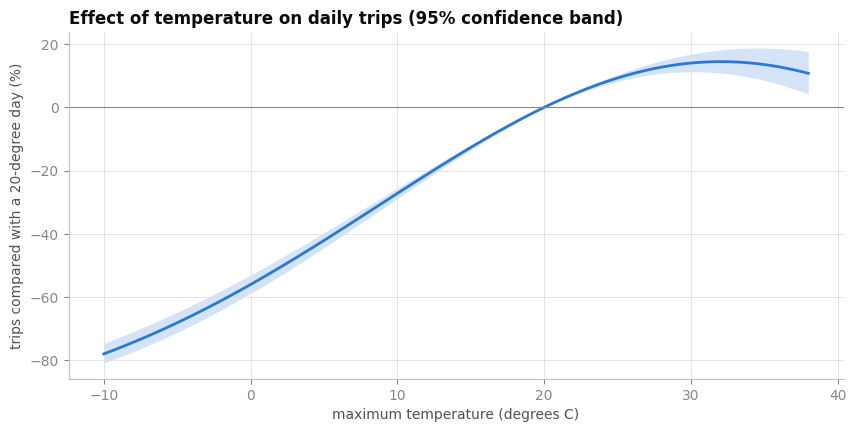

  0 degrees: -56% against 20 degrees
 10 degrees: -27% against 20 degrees
 30 degrees: +14% against 20 degrees
Highest expected demand at about 32 degrees


In [9]:
temperatures = np.arange(-10, 38.5, 0.5)
log_effect, log_se = temperature_effect(total_model, temperatures)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(temperatures, 100 * (np.exp(log_effect - 1.96 * log_se) - 1),
                100 * (np.exp(log_effect + 1.96 * log_se) - 1), color=BLUE, alpha=0.2, linewidth=0)
ax.plot(temperatures, 100 * (np.exp(log_effect) - 1), color=BLUE, linewidth=2)
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_xlabel("maximum temperature (degrees C)")
ax.set_ylabel("trips compared with a 20-degree day (%)")
ax.set_title("Effect of temperature on daily trips (95% confidence band)", loc="left")
plt.show()

peak = temperatures[np.argmax(log_effect)]
for t in (0, 10, 30):
    print(f"{t:>3} degrees: {100 * (np.exp(log_effect[temperatures == t][0]) - 1):+.0f}% against 20 degrees")
print(f"Highest expected demand at about {peak:.0f} degrees")

Temperature has the largest effect of all. A day with a maximum of 0 degrees has about 56% fewer trips than a 20-degree day in the same month, a 10-degree day about 27% fewer. Above 20 degrees the gain becomes smaller and the curve tops out at about 32 degrees (+14%); on the hottest days demand no longer rises. The narrow band shows that these numbers are well determined; only at the extremes, where there are few days, does it widen.

That the effect is so large **within** a month matters: a cold day in April is not just "April", it really keeps people off the bike.

### 2.6 Members and casual riders

01a suggested that members commute and casual riders ride for leisure. If so, casual riders should be easier to put off: a commute has to happen anyway, a leisure ride can be skipped. We fit the same model separately for the trips of members and of casual riders, and compare the weather effects.

In [10]:
effects_by_user = {}
for user_type in ("member", "casual"):
    model = fit_weather_model(user_type, data=model_data[model_data[user_type] > 0])
    effects = weather_effects(model)
    cold, cold_se = temperature_effect(model, 0)
    effects.loc["0 instead of 20 C"] = (100 * (np.exp([cold[0], cold[0] - 1.96 * cold_se[0],
                                                        cold[0] + 1.96 * cold_se[0]]) - 1)).round(1)
    effects_by_user[user_type] = effects
    print(f"{user_type}: R-squared {model.rsquared:.3f}")
comparison = pd.concat(effects_by_user, axis=1)
comparison

member: R-squared 0.890
casual: R-squared 0.942


member                            casual                       
                  effect_pct ci_low_pct ci_high_pct effect_pct ci_low_pct ci_high_pct
light                   -8.6      -10.5        -6.8      -15.6      -17.9       -13.3
moderate               -21.4      -23.4       -19.4      -35.1      -37.5       -32.5
heavy                  -35.9      -38.5       -33.1      -51.0      -53.9       -47.8
very heavy             -51.8      -56.0       -47.3      -69.4      -73.0       -65.3
snow on ground         -23.5      -31.0       -15.2      -38.0      -45.7       -29.3
0 instead of 20 C      -52.1      -55.2       -48.7      -79.9      -81.4       -78.2

The bar chart compares the effects with their 95% intervals (the error bars).

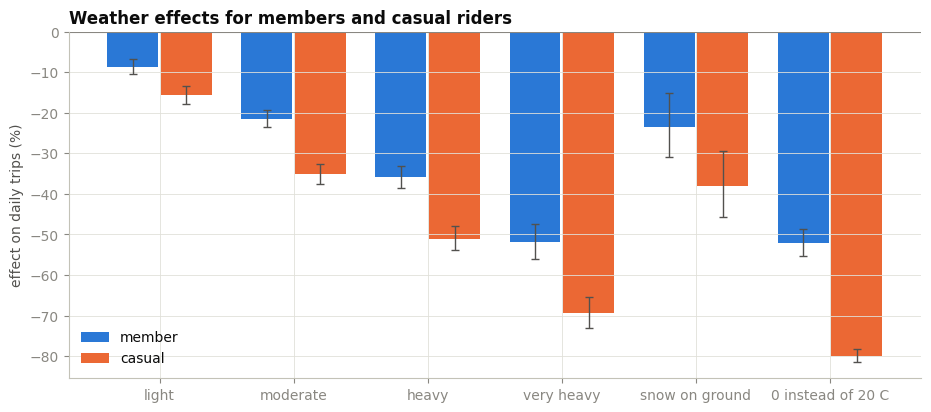

In [11]:
labels = list(comparison.index)
positions = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 4.5))
for offset, user_type in [(-0.2, "member"), (0.2, "casual")]:
    part = comparison[user_type]
    errors = np.vstack([part.effect_pct - part.ci_low_pct, part.ci_high_pct - part.effect_pct])
    ax.bar(positions + offset, part.effect_pct, width=0.38, color=USER_COLOURS[user_type], label=user_type,
           yerr=errors, error_kw={"ecolor": INK_SECONDARY, "elinewidth": 1, "capsize": 3})
ax.set_xticks(positions, labels)
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylabel("effect on daily trips (%)")
ax.set_title("Weather effects for members and casual riders", loc="left")
ax.legend(loc="lower left", frameon=False)
plt.show()

Casual riders react much more strongly to every kind of bad weather. Heavy rain costs 51% of the casual trips against 36% of the member trips, very heavy rain 69% against 52%, snow on the ground 38% against 24%, and a freezing day (0 instead of 20 degrees) 80% against 52%. For the rain classes the intervals of the two groups do not overlap. This fits the picture of members who ride because they have to get somewhere and casual riders who ride because they want to; it is one of the hypotheses we will test properly in `01c`.

### 2.7 Robustness: wind, and how well the model fits

Two checks of the model before we rely on it:

1. **Wind.** Strong wind could be the real cause of what we attribute to rain (storms bring both). Wind is missing on 226 days, so we fit the model again on the days with wind and add the average wind speed.
2. **Fit over time.** The predicted and the actual trips of 2025 side by side show whether the model follows the real ups and downs or only the average.

In [12]:
with_wind = model_data[model_data.wind_ms.notna()]
wind_model = fit_weather_model("total", data=with_wind, extra=" + wind_ms")
wind_effect = 100 * (np.exp(wind_model.params["wind_ms"]) - 1)
wind_ci = 100 * (np.exp(wind_model.conf_int().loc["wind_ms"]) - 1)
print(f"Wind: {wind_effect:.1f}% per m/s (95% interval {wind_ci[0]:.1f}% to {wind_ci[1]:.1f}%), "
      f"{int(wind_model.nobs):,} days")
pd.concat({"without wind": weather_effects(total_model).effect_pct,
           "with wind": weather_effects(wind_model).effect_pct}, axis=1)

Wind: -4.0% per m/s (95% interval -5.1% to -2.8%), 4,604 days


,without wind,with wind
light,-9.7,-9.8
moderate,-23.3,-23.1
heavy,-37.9,-36.9
very heavy,-54.1,-52.8
snow on ground,-24.3,-26.7


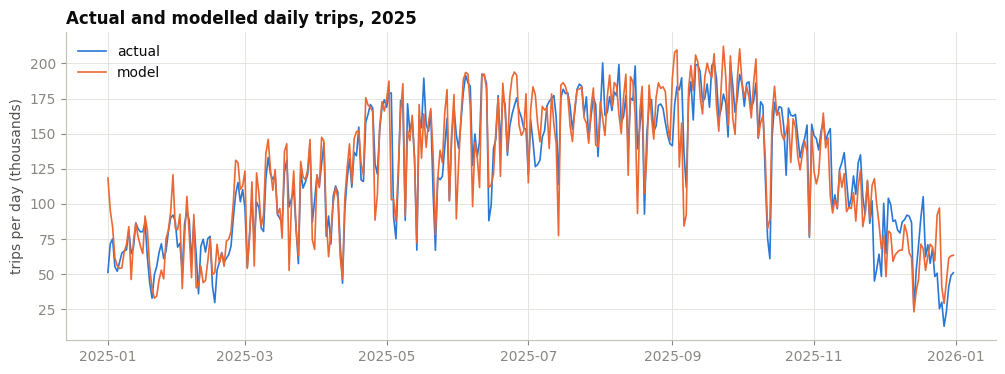

2025: the model is within 10% of the actual trips on 55% of the days, within 20% on 78%
Largest overestimates in 2025 (actual against model, %):
DATE
2025-12-25   -74.0
2025-11-27   -62.0
2025-01-01   -57.0
2025-12-27   -56.0
2025-12-28   -48.0
2025-11-28   -46.0


In [13]:
year_2025 = model_data.index.year == 2025
fitted = np.exp(total_model.fittedvalues[year_2025])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(model_data.index[year_2025], model_data.total[year_2025] / 1e3, color=BLUE, linewidth=1.2, label="actual")
ax.plot(fitted.index, fitted / 1e3, color=ORANGE, linewidth=1.2, label="model")
ax.set_ylabel("trips per day (thousands)")
ax.set_title("Actual and modelled daily trips, 2025", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()
residual_pct = 100 * (model_data.total[year_2025] / fitted - 1)
print(f"2025: the model is within 10% of the actual trips on {(residual_pct.abs() <= 10).mean():.0%} of the days, "
      f"within 20% on {(residual_pct.abs() <= 20).mean():.0%}")
print("Largest overestimates in 2025 (actual against model, %):")
print(residual_pct.sort_values().head(6).round(0).to_string())

- **Wind** has its own effect: every metre per second of average wind costs about 4% of the trips. Adding it barely changes the rain and snow effects, so they are not wind in disguise.
- **Fit:** the model follows the actual 2025 trips day by day, including most of the sharp dips, which are rain days. It is within 10% of the actual trips on 55% of the days and within 20% on 78% (median error about 9%). Its largest misses in 2025 are holidays, which are much quieter than the weather predicts: Christmas Day 74% fewer trips than expected, Thanksgiving 62%, New Year's Day 57%, and the days between Christmas and New Year. Holidays are therefore examined in the next step. Other misses probably come from the timing of rain within the day, which a daily total cannot show.

Limitations to keep in mind: one weather station for the whole city; a daily total cannot tell a morning shower from an evening one; and the model is descriptive, not a forecast (it uses the same month's average level, which is not known in advance).

### 2.8 Conclusion of step 1

- The weather is the strongest day-to-day driver of bike use: within the same month, a day of 0 degrees has about half the trips of a 20-degree day, heavy rain costs over a third and very heavy rain over half. Together with weekday and month it explains 90% of the daily variation.
- All 10 days without trips (and the near-empty days) were snowstorms; the system was closed.
- Casual riders are much more weather-sensitive than members.

For the "going green" theme this means that whether people choose the bike depends strongly on conditions they cannot control; for a model of daily demand, weather is an essential input. The next steps of this notebook look at the patterns over time (weekdays, holidays, members and casual riders), the bikes and the stations.

## 3. Time patterns: who rides when

01a showed two kinds of use: commuting peaks on working days and leisure at weekends, with members dominating the first and casual riders the second. This section measures those patterns with evidence: the weekday effects, the effect of public holidays (a holiday removes the commute but keeps the free time, so it is a natural test of the commuter idea), the hour profile, and whether the two groups have changed over the years.

### 3.1 Weekdays and public holidays

We extend the weather model of section 2 with two terms:

- `holiday`: the US federal holidays (New Year's Day, Martin Luther King Day, Washington's Birthday, Memorial Day, Juneteenth (since 2021), Independence Day, Labor Day, Columbus Day, Veterans Day, Thanksgiving and Christmas Day), from pandas' `USFederalHolidayCalendar`;
- `christmas_week`: the other days from 24 December to 1 January, when many people are off work.

Weather, weekday and month stay in the model, so a holiday is compared with the same weekday in the same month under the same weather. As before, the model is fitted separately for members and casual riders.

In [14]:
from pandas.tseries.holiday import USFederalHolidayCalendar

holidays = USFederalHolidayCalendar().holidays(FIRST_DAY, LAST_DAY, return_name=True)
month_day = model_data.index.strftime("%m-%d")
model_data["holiday"] = model_data.index.isin(holidays.index).astype(int)
model_data["christmas_week"] = (((month_day >= "12-24") | (month_day <= "01-01"))
                                & (model_data.holiday == 0)).astype(int)
model_data["holiday_name"] = holidays.reindex(model_data.index).fillna("")
print(f"{model_data.holiday.sum()} holidays and {model_data.christmas_week.sum()} other Christmas-week days "
      f"among {len(model_data):,} days")

WEEKDAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


def percent_effects(model, terms, names=None):
    """Percentage effects with 95% intervals for the given model terms."""
    ci = model.conf_int().loc[terms]
    table = pd.DataFrame({"effect_pct": 100 * (np.exp(model.params[terms]) - 1),
                          "ci_low_pct": 100 * (np.exp(ci[0]) - 1),
                          "ci_high_pct": 100 * (np.exp(ci[1]) - 1)}).round(1)
    if names is not None:
        table.index = names
    return table


calendar_models, calendar_effects = {}, {}
for user_type in ("member", "casual"):
    model = fit_weather_model(user_type, data=model_data[model_data[user_type] > 0],
                              extra=" + holiday + christmas_week")
    calendar_models[user_type] = model
    weekday_terms = [f"C(weekday)[T.{d}]" for d in range(1, 7)]
    calendar_effects[user_type] = percent_effects(
        model, weekday_terms + ["holiday", "christmas_week"],
        names=WEEKDAY_NAMES[1:] + ["federal holiday", "Christmas week"])
calendar_table = pd.concat(calendar_effects, axis=1)
calendar_table

137 holidays and 93 other Christmas-week days among 4,830 days


member                            casual                       
                effect_pct ci_low_pct ci_high_pct effect_pct ci_low_pct ci_high_pct
Tuesday                5.4        3.2         7.6       -2.9       -5.6        -0.1
Wednesday              6.4        4.0         8.9       -2.2       -5.4         1.2
Thursday               4.5        1.7         7.5        2.7       -0.7         6.3
Friday                -0.4       -2.9         2.2       19.2       15.4        23.2
Saturday             -21.7      -23.9       -19.4       83.9       76.8        91.4
Sunday               -28.1      -29.9       -26.3       63.3       57.8        69.1
federal holiday      -39.5      -44.1       -34.5       37.8       28.4        48.0
Christmas week       -39.0      -43.3       -34.3       12.9       -2.8        31.2

The weekday effects are compared with Monday (same weather, same month), the holiday effects with an ordinary day of the same weekday. The chart shows both groups side by side.

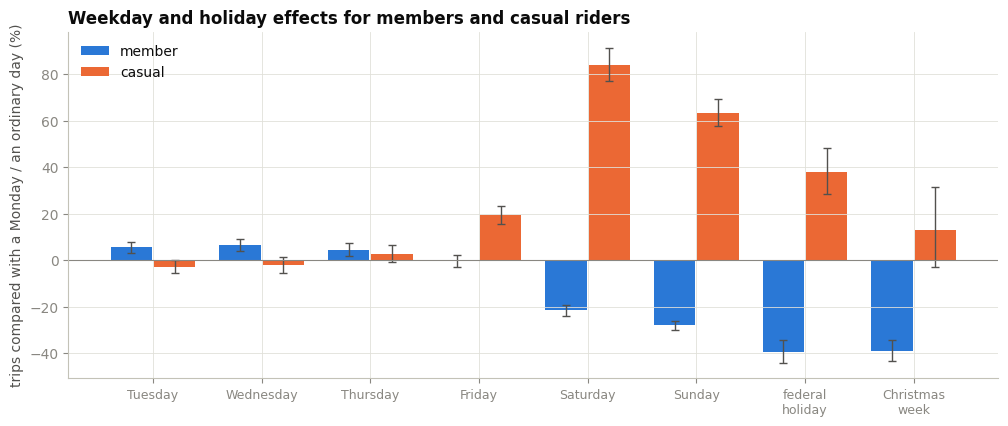

In [15]:
labels = list(calendar_table.index)
positions = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(12, 4.5))
for offset, user_type in [(-0.2, "member"), (0.2, "casual")]:
    part = calendar_table[user_type]
    errors = np.vstack([part.effect_pct - part.ci_low_pct, part.ci_high_pct - part.effect_pct])
    ax.bar(positions + offset, part.effect_pct, width=0.38, color=USER_COLOURS[user_type], label=user_type,
           yerr=errors, error_kw={"ecolor": INK_SECONDARY, "elinewidth": 1, "capsize": 3})
ax.set_xticks(positions, [label.replace(" ", "\n") for label in labels], fontsize=9)
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylabel("trips compared with a Monday / an ordinary day (%)")
ax.set_title("Weekday and holiday effects for members and casual riders", loc="left")
ax.legend(loc="upper left", frameon=False)
plt.show()

The two groups mirror each other:

- **Members** ride most from Tuesday to Thursday (4.5% to 6.4% more than on Monday) and much less at weekends (Saturday -22%, Sunday -28%).
- **Casual riders** ride most at weekends: Saturday +84%, Sunday +63% compared with Monday, and Friday is already 19% busier.
- On a **federal holiday** member trips fall by 40% (95% interval -44% to -35%), while casual trips **rise** by 38% (+28% to +48%). On the other days of the Christmas week (24 December to 1 January) member trips fall by 39%; for casual riders the effect is uncertain (+13%, interval -3% to +31%).

A holiday behaves like a weekend: it removes the commute and adds free time. That members lose 40% of their trips on a holiday is strong evidence that a large part of member use is commuting.

Not every holiday is the same, though. The table below shows, per holiday, how far the trips were below or above what the weather model of section 2 (without holiday terms) expected, as the median over the years.

In [16]:
per_holiday = {}
for user_type in ("member", "casual"):
    base_model = fit_weather_model(user_type, data=model_data[model_data[user_type] > 0])
    surprise = 100 * (np.exp(base_model.resid) - 1)  # actual against expected, in %
    names = model_data.holiday_name.reindex(surprise.index)
    per_holiday[user_type] = surprise[names != ""].groupby(names[names != ""]).median().round(0)
per_holiday = pd.DataFrame(per_holiday).sort_values("member")
per_holiday["years"] = model_data[model_data.holiday == 1].holiday_name.value_counts()
per_holiday

,member,casual,years
holiday_name,,,
Christmas Day,-73.0,17.0,13
Thanksgiving Day,-68.0,-12.0,13
New Year's Day,-56.0,59.0,13
Independence Day,-40.0,39.0,14
Labor Day,-35.0,34.0,13
Memorial Day,-26.0,63.0,13
Washington's Birthday,-20.0,27.0,13
Columbus Day,-16.0,2.0,13
"Birthday of Martin Luther King, Jr.",-10.0,50.0,13


The holidays on which most people are off work hit member trips hardest: Christmas Day (-73%), Thanksgiving (-68%) and New Year's Day (-56%), then Independence Day and Labor Day. On holidays that many private employers do not give, member trips change least: Veterans Day +5%, Juneteenth -9%, Martin Luther King Day -10%. Casual trips rise on most holidays, most of all on Memorial Day and New Year's Day; only on Thanksgiving, a family day at home, do they fall. The pattern follows who is off work, which again points to commuting as the main use by members.

### 3.2 The hour of the day

Section 8 of 01a showed the rush-hour peaks for all trips. Here we split them by user type, for working days only (no weekends, no holidays), and compare 2019 (before COVID-19) with 2025.

228,844 rows (day x hour x user type), built in 35 s


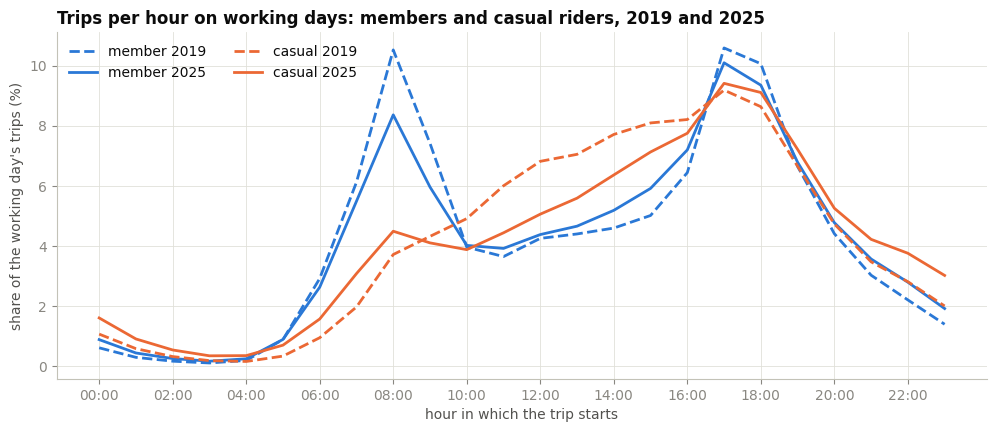

In [17]:
start = time.time()
hourly = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, hour(started_at) AS hour, user_type, count(*) AS trips
    FROM clean_trips WHERE started_at >= DATE '2013-06-01' AND user_type IS NOT NULL GROUP BY ALL
""").df()
hourly["day"] = pd.to_datetime(hourly.day)
working = hourly[(hourly.day.dt.dayofweek < 5) & ~hourly.day.isin(holidays.index)]
print(f"{len(hourly):,} rows (day x hour x user type), built in {time.time() - start:.0f} s")

fig, ax = plt.subplots(figsize=(12, 4.5))
for user_type in ("member", "casual"):
    for year, style in [(2019, "--"), (2025, "-")]:
        part = working[(working.user_type == user_type) & (working.day.dt.year == year)]
        profile = part.groupby("hour").trips.sum()
        ax.plot(profile.index, profile / profile.sum() * 100, color=USER_COLOURS[user_type], linestyle=style,
                linewidth=2, label=f"{user_type} {year}")
ax.set_xticks(range(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_xlabel("hour in which the trip starts")
ax.set_ylabel("share of the working day's trips (%)")
ax.set_title("Trips per hour on working days: members and casual riders, 2019 and 2025", loc="left")
ax.legend(loc="upper left", frameon=False, ncol=2)
plt.show()

On working days members have sharp peaks at 08:00 and 17:00, the typical commute. Casual riders have a gentler curve that rises through the day to a late-afternoon maximum. Between 2019 and 2025 the two curves moved towards each other: the members' morning peak dropped clearly (from 10.5% to 8.4% of the day's trips in the hour from 08:00) while their evening peak hardly changed, and casual riders gained a small morning peak and lost part of their midday trips.

To put a number on this we use the **rush-hour share**: the share of a working day's trips that start between 07:00 and 09:00 or between 17:00 and 19:00. We compute it for every working day and every group, and average it per year.

In [18]:
RUSH_HOURS = [7, 8, 17, 18]
rush = (working.assign(rush=working.hour.isin(RUSH_HOURS))
        .groupby(["day", "user_type", "rush"]).trips.sum().unstack(fill_value=0))
rush_share = (rush[True] / rush.sum(axis=1) * 100).unstack()  # one row per working day, a column per group
rush_by_year = rush_share.groupby(rush_share.index.year).mean().round(1)
rush_by_year.T

day,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
user_type,,,,,,,,,,,,,,
casual,21.9,21.6,20.8,19.5,19.6,20.2,22.9,26.2,25.1,25.3,25.4,26.0,26.4,26.5
member,35.5,36.1,37.4,37.8,37.7,37.0,37.0,31.6,31.1,32.2,32.4,32.7,33.2,33.0


Two questions with an effect size and a confidence interval, using the daily values. Neighbouring days are again correlated, so the intervals come from a regression with Newey-West (HAC) standard errors, as in section 2.

1. How much higher is the members' rush-hour share than the casual riders' in 2025? (a paired comparison: both groups on the same days)
2. How much did the members' rush-hour share change between 2017-2019 and 2023-2025?

In [19]:
def mean_with_hac_ci(values):
    """Mean of a daily series with a 95% interval that allows for correlation between neighbouring days."""
    fit = smf.ols("y ~ 1", data=pd.DataFrame({"y": values})).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
    low, high = fit.conf_int().loc["Intercept"]
    return round(fit.params["Intercept"], 2), round(low, 2), round(high, 2)


paired_2025 = (rush_share.member - rush_share.casual)[rush_share.index.year == 2025].dropna()
print("1. Member minus casual rush-hour share in 2025 (percentage points): "
      "%.2f (95%% interval %.2f to %.2f), %d working days" % (*mean_with_hac_ci(paired_2025), len(paired_2025)))

members = rush_share.member.dropna().to_frame("share")
members["period"] = np.select([members.index.year.isin([2017, 2018, 2019]), members.index.year.isin([2023, 2024, 2025])],
                              ["2017-2019", "2023-2025"], "other")
members = members[members.period != "other"]
change = smf.ols("share ~ C(period)", data=members).fit(cov_type="HAC", cov_kwds={"maxlags": 7})
term = "C(period)[T.2023-2025]"
low, high = change.conf_int().loc[term]
print(f"2. Members' rush-hour share 2023-2025 against 2017-2019: {change.params[term]:+.2f} percentage points "
      f"(95% interval {low:+.2f} to {high:+.2f}), from {change.params['Intercept']:.1f}%")

1. Member minus casual rush-hour share in 2025 (percentage points): 6.77 (95% interval 6.57 to 6.97), 250 working days
2. Members' rush-hour share 2023-2025 against 2017-2019: -4.47 percentage points (95% interval -4.99 to -3.95), from 37.2%


- Before COVID-19 about 37% of the members' working-day trips started in the four rush hours; since 2020 it is 31-33%. The drop of about 4.5 percentage points between 2017-2019 and 2023-2025 has a narrow interval, so it is not noise. A likely explanation is hybrid work: fewer people commute every day since the pandemic. The data cannot prove that cause, but the timing (a break in 2020 that never recovered) fits it.
- Casual riders went the other way, from about 20-23% before 2020 to 25-26% since. In 2025 members still have a clearly higher rush-hour share than casual riders (6.8 percentage points, interval 6.6 to 7.0), but the gap was 14-18 points before 2020.

### 3.3 Trip duration

01a found that casual trips last longer on average. Averages are pulled up by long rides, so here we use the **median** duration per day and per group (trips with a known end, rule S1), and look at it per year.

Daily medians built in 56 s


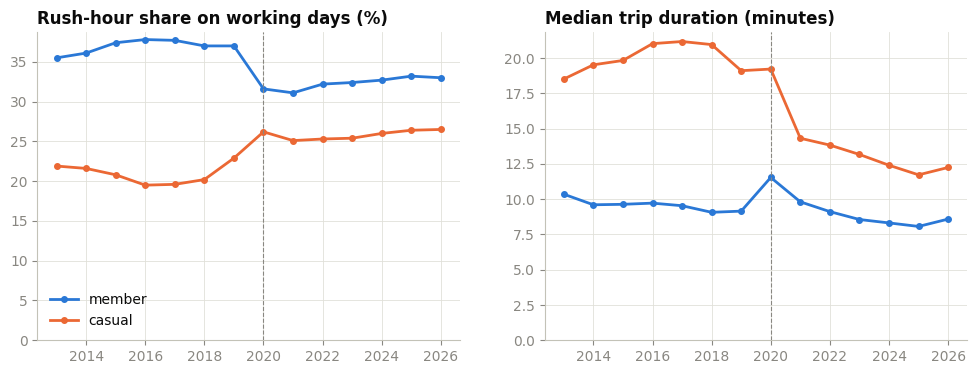

day,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
user_type,,,,,,,,,,,,,,
casual,18.5,19.5,19.8,21.0,21.2,21.0,19.1,19.2,14.3,13.8,13.2,12.4,11.7,12.2
member,10.4,9.6,9.6,9.7,9.5,9.1,9.2,11.5,9.8,9.1,8.6,8.3,8.1,8.6


In [20]:
start = time.time()
durations = con.sql("""
    SELECT CAST(started_at AS DATE) AS day, user_type, median(duration) / 60 AS median_minutes
    FROM clean_trips
    WHERE started_at >= DATE '2013-06-01' AND user_type IS NOT NULL
          AND (end_station_id IS NOT NULL OR end_lat IS NOT NULL)
    GROUP BY ALL
""").df()
durations["day"] = pd.to_datetime(durations.day)
durations = durations.pivot(index="day", columns="user_type", values="median_minutes")
print(f"Daily medians built in {time.time() - start:.0f} s")

by_year = durations.groupby(durations.index.year).median()
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
for user_type in ("member", "casual"):
    left.plot(rush_by_year.index, rush_by_year[user_type], color=USER_COLOURS[user_type], linewidth=2,
              marker="o", markersize=4, label=user_type)
    right.plot(by_year.index, by_year[user_type], color=USER_COLOURS[user_type], linewidth=2,
               marker="o", markersize=4, label=user_type)
left.set_title("Rush-hour share on working days (%)", loc="left")
right.set_title("Median trip duration (minutes)", loc="left")
for ax in (left, right):
    ax.axvline(2020, color=INK_MUTED, linewidth=0.8, linestyle="--")
    ax.set_ylim(0, None)
left.legend(loc="lower left", frameon=False)
plt.show()
by_year.round(1).T

In [21]:
difference_2025 = (durations.casual - durations.member)[durations.index.year == 2025].dropna()
print("Casual minus member median duration in 2025 (minutes): %.2f (95%% interval %.2f to %.2f), %d days"
      % (*mean_with_hac_ci(difference_2025), len(difference_2025)))

Casual minus member median duration in 2025 (minutes): 3.63 (95% interval 3.34 to 3.92), 365 days


The median member trip has lasted 8 to 10 minutes in almost every year (11.5 in 2020, the pandemic year; 8.1 in 2025). The median casual trip lasted about 18.5 to 21 minutes until 2020 and then became much shorter: 11.7 minutes in 2025. A casual trip is still clearly longer than a member trip (by 3.6 minutes in 2025, interval 3.3 to 3.9), but the gap shrank from 10-12 minutes before 2020 to less than 4.

Together with 3.2 this shows that **the two groups are converging**: casual riders ride shorter and more often in the rush hours, as if more of them use the bike for transport, while members commute less in the rush hours than before 2020. The data does not tell us why. Possible reasons, which we cannot test with this data, are changes in pricing (e.g. paying per minute for electric bikes), more casual riders who use the bike as transport without a subscription, and hybrid work.

### 3.4 Conclusion of step 2

- **Commuting is the core of member use:** members ride most on working days, lose 22-28% at weekends and 40% on federal holidays (up to 73% on Christmas Day), and have sharp rush-hour peaks.
- **Casual use is leisure:** casual trips rise at weekends (+84% on Saturday) and on holidays (+38%), and are more weather-sensitive (section 2).
- **Since 2020 the groups are converging:** members' rush-hour share fell from about 37% to 33%, casual riders' rose from about 21% to 26%, and the median casual trip fell from about 20 to 12 minutes.

For a model these are useful findings: the user type can be predicted from when and how long someone rides (one of the candidate targets), but less easily now than before 2020. For daily demand, holidays need their own feature next to the weather.